找到 744 个CSV文件
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241003110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241004110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241005110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241007110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241008110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241010110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241012110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241016110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241019110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241020110000_0000-0000.CSV: 'Mean Bias'列无有效数据
文件 MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241022110000_0000-0000.CSV: 'Mean Bi

C:\Users\111\AppData\Local\Temp\ipykernel_30844\3935275763.py:186: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
e:\miniconda\envs\data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


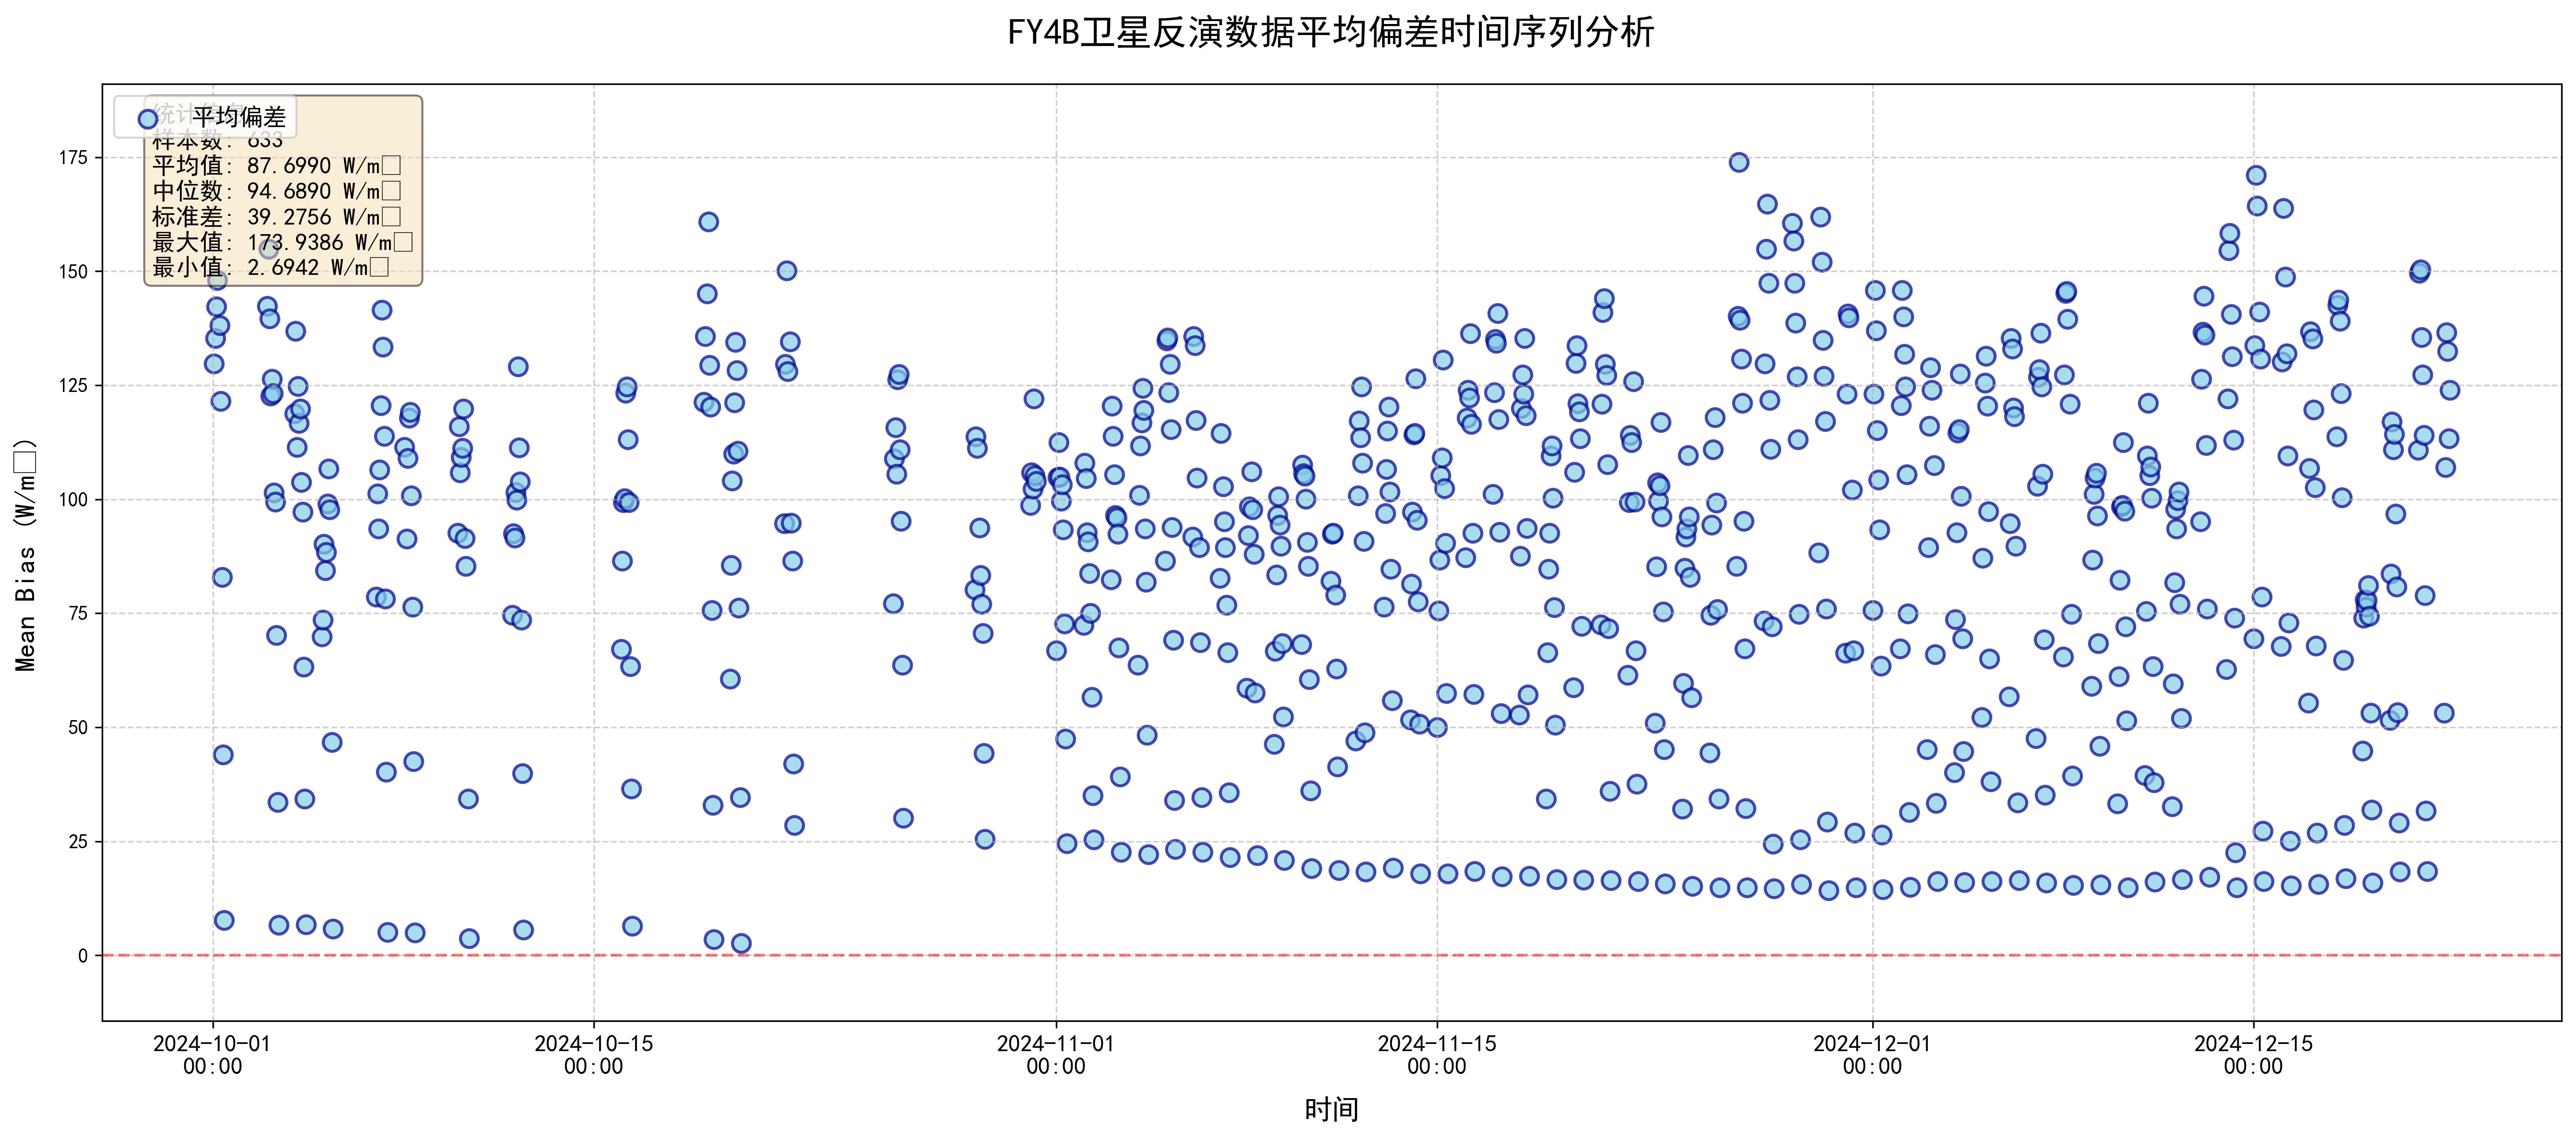


趋势分析:
斜率: -0.033961 W/m²/小时
R²值: 0.0004
显著性: p值 = 0.616744 (不显著，p ≥ 0.05)
趋势: 无明显趋势


In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import mplcursors
from matplotlib.dates import DateFormatter, AutoDateLocator
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from scipy import stats

# 设置中文字体显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 基础路径
base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"

def read_and_process_file(file):
    """读取并处理单个文件，返回时间戳和Mean Bias数据"""
    try:
        # 从文件名提取时间信息
        filename = os.path.basename(file)
        date_str = filename.split('_')[-2][:10]  # 提取 YYYYMMDDHH
        time_obj = datetime.strptime(date_str, '%Y%m%d%H')
        
        # 读取CSV文件，增加错误处理
        ssi_csv = pd.read_csv(file, encoding='utf-8', sep=',')
        
        # 数据清洗和异常值处理
        ssi_csv = ssi_csv.replace([-999, 999999, 'NaN', 'NA', 'nan', 'NAN'], np.nan)
        
        # 检查是否存在Mean Bias列
        if 'Mean Bias' not in ssi_csv.columns:
            print(f"文件 {filename} 中不存在'Mean Bias'列，可用列名: {', '.join(ssi_csv.columns)}")
            return time_obj, None
        
        # 计算统计量
        mean_bias = ssi_csv['Mean Bias'].dropna()
        
        # 应用3-sigma原则过滤异常值
        if len(mean_bias) > 10:  # 数据点足够多时才进行过滤
            mean_val = mean_bias.mean()
            std_val = mean_bias.std()
            filtered_bias = mean_bias[(mean_bias >= mean_val - 3*std_val) & 
                                      (mean_bias <= mean_val + 3*std_val)]
            
            if len(filtered_bias) < len(mean_bias):
                print(f"文件 {filename}: 过滤了 {len(mean_bias) - len(filtered_bias)} 个异常值")
            mean_bias = filtered_bias
            
        # 计算平均偏差
        if not mean_bias.empty:
            return time_obj, mean_bias.mean()
        else:
            print(f"文件 {filename}: 'Mean Bias'列无有效数据")
            return time_obj, None
            
    except Exception as e:
        print(f"处理文件 {file} 时出错: {str(e)}")
        return None, None

def main():
    # 使用glob递归查找所有csv文件
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        print("未找到匹配的CSV文件")
        return
    
    print(f"找到 {len(file_list)} 个CSV文件")
    
    # 存储所有Mean Bias数据和对应的时间
    time_data = []
    mean_bias_data = []
    valid_files = 0
    
    for file in file_list:
        time_obj, mean_bias = read_and_process_file(file)
        if time_obj and mean_bias is not None:
            time_data.append(time_obj)
            mean_bias_data.append(mean_bias)
            valid_files += 1
    
    print(f"成功处理 {valid_files} 个文件")
    
    if not mean_bias_data:
        print("没有有效数据用于绘图")
        return
    
    # 绘制交互式图像
    # 创建大画布（宽度增加以便放大时间间隔）
    fig, ax = plt.subplots(figsize=(18, 8))
    
    # 按时间排序
    sorted_data = sorted(zip(time_data, mean_bias_data), key=lambda x: x[0])
    time_sorted, bias_sorted = zip(*sorted_data)
    
    # 计算统计信息
    bias_series = pd.Series(bias_sorted, index=time_sorted)
    rolling_mean = bias_series.rolling(window=5).mean()  # 5点移动平均
    rolling_std = bias_series.rolling(window=5).std()    # 5点移动标准差
    
    # 绘制原始数据曲线
    scatter = ax.scatter(
        time_sorted, 
        bias_sorted, 
        s=80,  # 标记大小
        c='skyblue', 
        edgecolors='darkblue',
        linewidths=1.5,
        alpha=0.7,
        label='平均偏差'
    )
    
    # # 绘制移动平均线
    # ax.plot(
    #     time_sorted, 
    #     rolling_mean, 
    #     'r-', 
    #     linewidth=2.5,
    #     alpha=0.8,
    #     label='5点移动平均'
    # )
    
    # # 绘制±1标准差区间
    # ax.fill_between(
    #     time_sorted,
    #     rolling_mean - rolling_std,
    #     rolling_mean + rolling_std,
    #     color='gray',
    #     alpha=0.2,
    #     label='±1标准差'
    # )
    
    # 设置标题和标签
    ax.set_title("FY4B卫星反演数据平均偏差时间序列分析", fontsize=18, pad=20)
    ax.set_xlabel("时间", fontsize=14, labelpad=10)
    ax.set_ylabel("Mean Bias (W/m²)", fontsize=14, labelpad=10)
    
    # 优化时间轴显示
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # 自动选择时间间隔
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))  # 格式化日期时间
    plt.xticks(rotation=0, ha='center', fontsize=12)  # 旋转标签避免重叠
    
    # 设置Y轴范围（根据数据自动调整）
    y_min = min(bias_sorted) - 0.1 * (max(bias_sorted) - min(bias_sorted))
    y_max = max(bias_sorted) + 0.1 * (max(bias_sorted) - min(bias_sorted))
    ax.set_ylim(y_min, y_max)
    
    # 添加网格和图例
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', fontsize=12)
    
    # 添加参考线
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='零偏差参考')
    
    # 添加悬停提示（增强版）
    cursor = mplcursors.cursor(scatter, hover=True)
    cursor.connect(
        "add", 
        lambda sel: sel.annotation.set_text(
            f"时间: {sel.target[0]:%Y-%m-%d %H:%M}\n"
            f"偏差值: {sel.target[1]:.4f} W/m²\n"
            f"移动平均: {rolling_mean[sel.index]:.4f} W/m²"
        )
    )
    
    # 添加统计信息文本框
    stats_text = (f"统计信息:\n"
                 f"样本数: {len(bias_sorted)}\n"
                 f"平均值: {np.mean(bias_sorted):.4f} W/m²\n"
                 f"中位数: {np.median(bias_sorted):.4f} W/m²\n"
                 f"标准差: {np.std(bias_sorted):.4f} W/m²\n"
                 f"最大值: {np.max(bias_sorted):.4f} W/m²\n"
                 f"最小值: {np.min(bias_sorted):.4f} W/m²")
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    # 自动调整布局并显示
    plt.tight_layout()
    plt.show()
    
    # 打印趋势分析结果
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        mdates.date2num(time_sorted), bias_sorted
    )
    
    print("\n趋势分析:")
    print(f"斜率: {slope:.6f} W/m²/小时")
    print(f"R²值: {r_value**2:.4f}")
    if p_value < 0.05:
        print(f"显著性: p值 = {p_value:.6f} (显著，p < 0.05)")
        if slope > 0:
            print("趋势: 平均偏差随时间呈上升趋势")
        else:
            print("趋势: 平均偏差随时间呈下降趋势")
    else:
        print(f"显著性: p值 = {p_value:.6f} (不显著，p ≥ 0.05)")
        print("趋势: 无明显趋势")

if __name__ == "__main__":
    main()

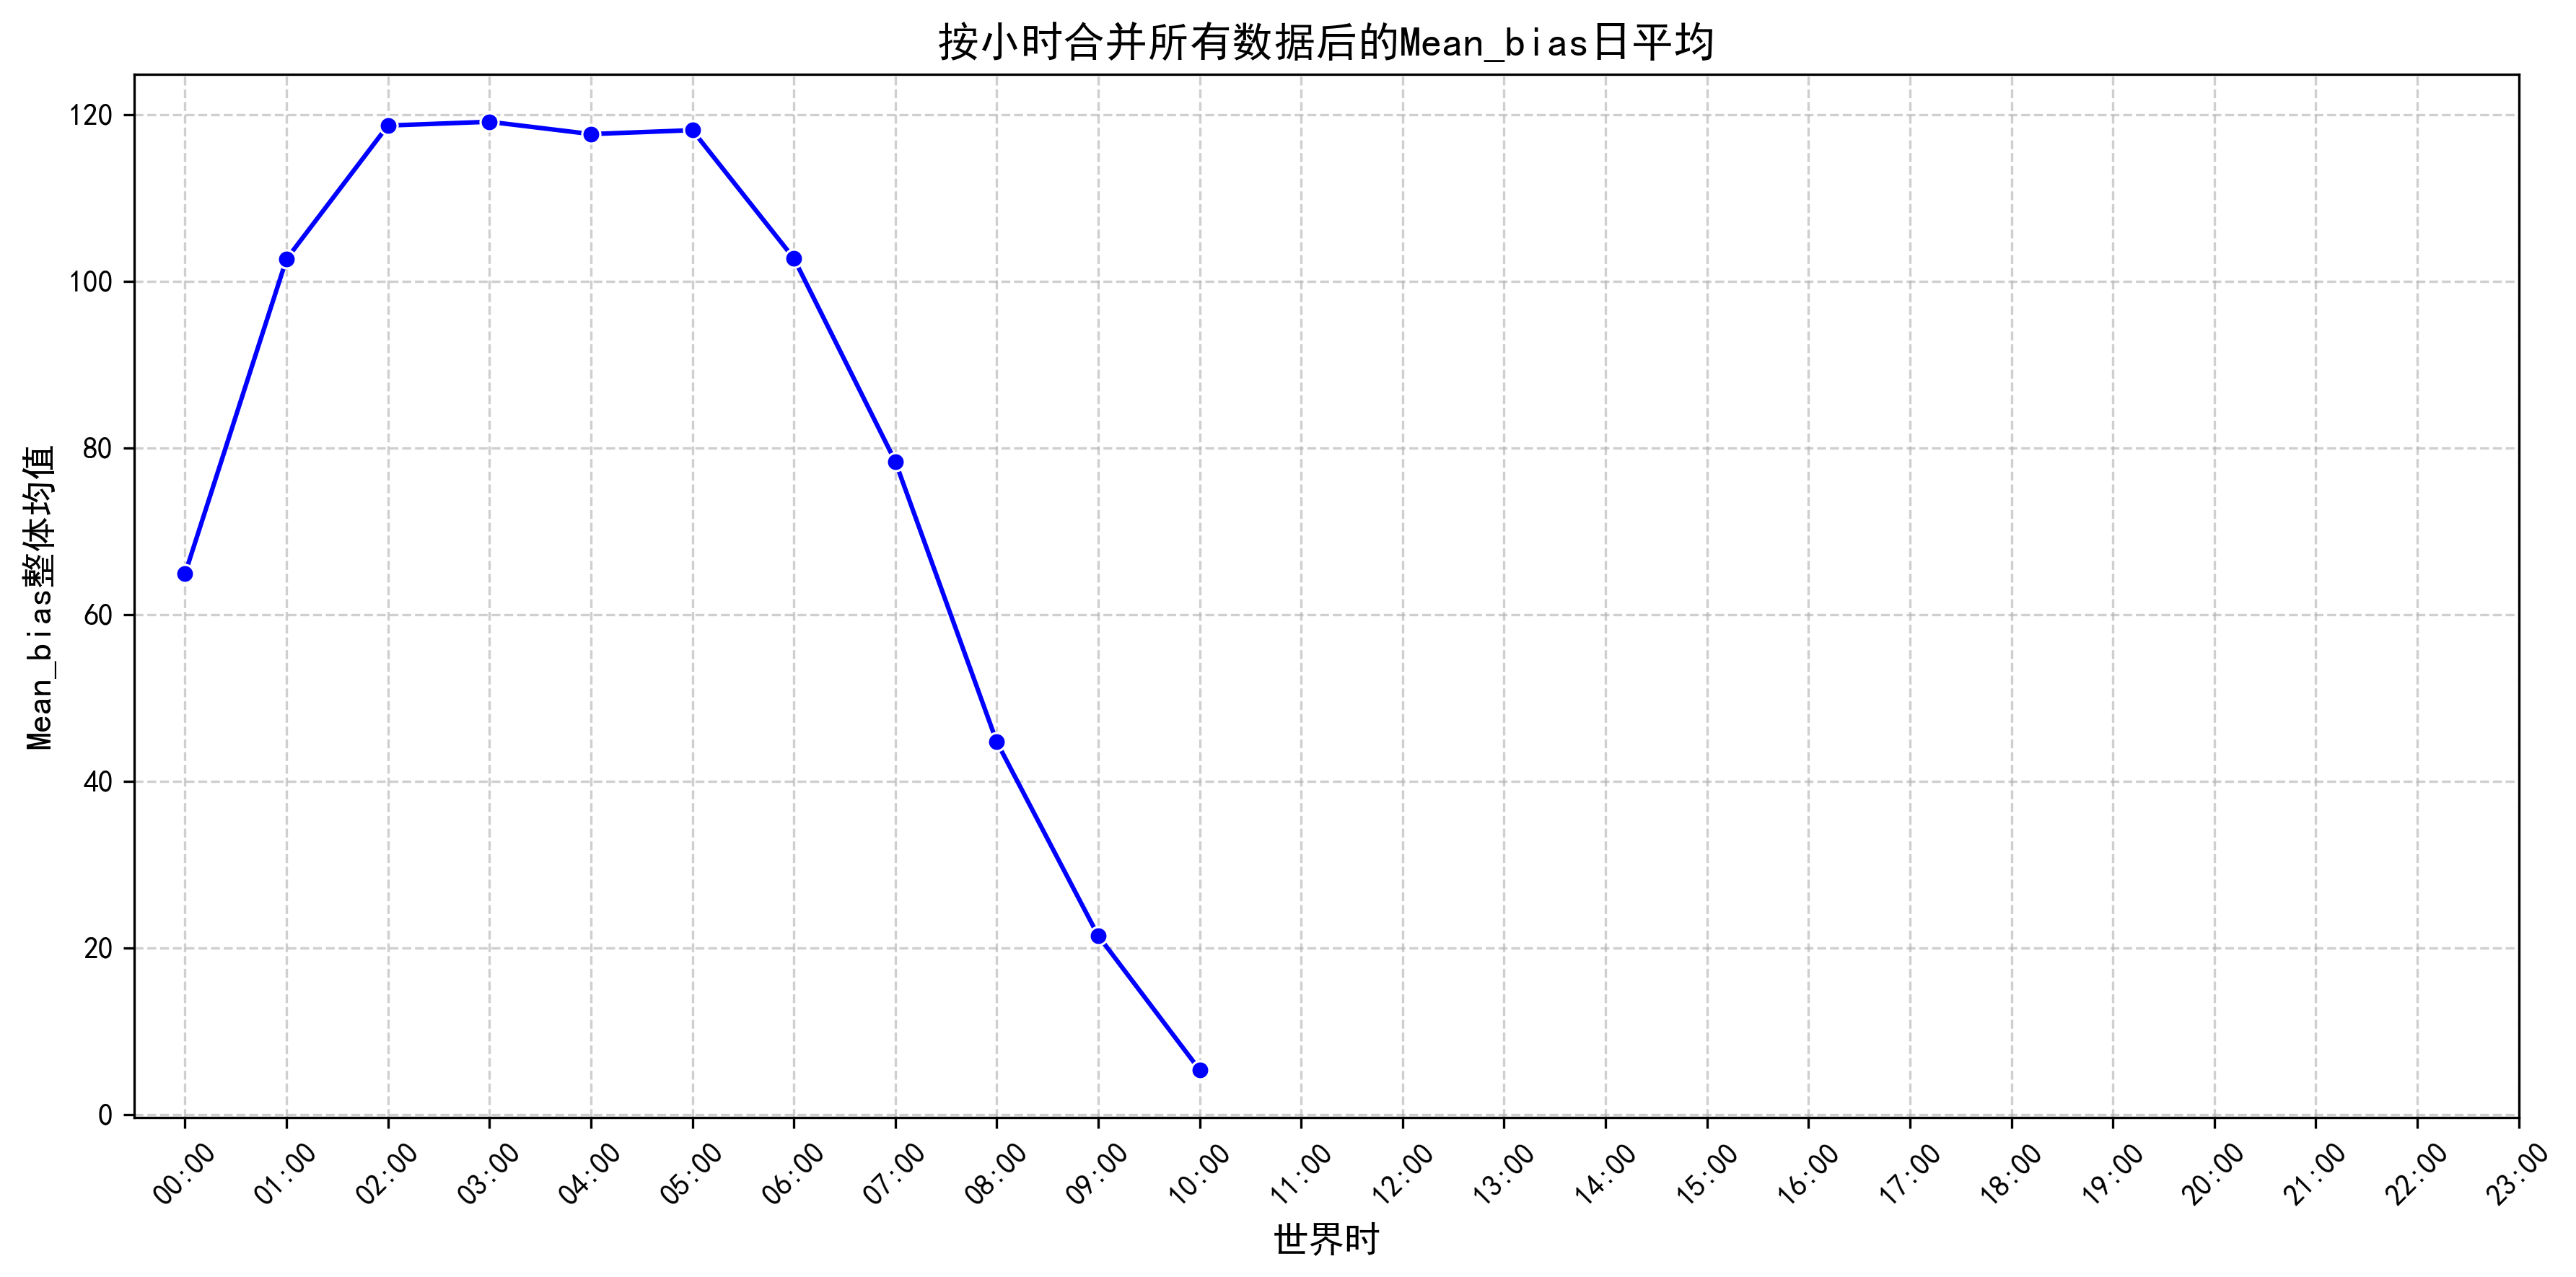

In [3]:
import pandas as pd
import glob
import os
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 基础路径
base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
file_list = glob.glob(file_pattern, recursive=True)

# 初始化字典：按小时存储所有Mean Bias数据（不预先计算单文件均值）
hourly_raw_data = {}

for file in file_list:
    try:
        # 提取小时
        filename = os.path.basename(file)
        datetime_str = filename.split('_')[-2][:10]  # 提取YYYYMMDDHH
        time_obj = datetime.strptime(datetime_str, "%Y%m%d%H")
        hour = time_obj.hour
        
        # 读取CSV文件
        df = pd.read_csv(file)
        
        # 检查列是否存在并提取所有Mean Bias数据
        if 'Mean Bias' in df.columns:
            valid_values = df['Mean Bias'].replace([-999],np.nan).dropna()  # 去除NaN
            if not valid_values.empty:
                if hour not in hourly_raw_data:
                    hourly_raw_data[hour] = []
                hourly_raw_data[hour].extend(valid_values.tolist())  # 合并原始数据
    
    except Exception as e:
        print(f"处理文件 {filename} 时出错: {e}")
        continue

# 计算每小时的整体均值
# hourly_avg = {}
# for hour, values in hourly_raw_data.items():
#     if values:  # 确保有数据
#         hourly_avg[hour] = np.mean(values)
#     else:
#         hourly_avg[hour] = np.nan  # 如果没有数据，设为NaN
hourly_avg = {hour: np.mean(values) for hour, values in hourly_raw_data.items()}

# 补全24小时（如果某些小时无数据，设为NaN）
hourly_avg_complete = {h: hourly_avg.get(h, np.nan) for h in range(24)}

# 转换为DataFrame用于绘图
df_plot = pd.DataFrame({
    'Hour': list(hourly_avg_complete.keys()),
    'Mean_bias': list(hourly_avg_complete.values())
})

# 绘制日平均分布图
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='Hour', y='Mean_bias', marker='o', color='b')
plt.title('按小时合并所有数据后的Mean_bias日平均', fontsize=14)
plt.xlabel('世界时', fontsize=12)
plt.ylabel('Mean_bias整体均值', fontsize=12)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

找到 744 个文件，开始处理...


处理文件中: 100%|██████████| 744/744 [00:02<00:00, 356.88it/s]


生成中国全境Bias填色图...
站点平均值清洗后保留 167 个有效站点
正在执行克里金插值...（可能需要几分钟）


e:\miniconda\envs\data\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


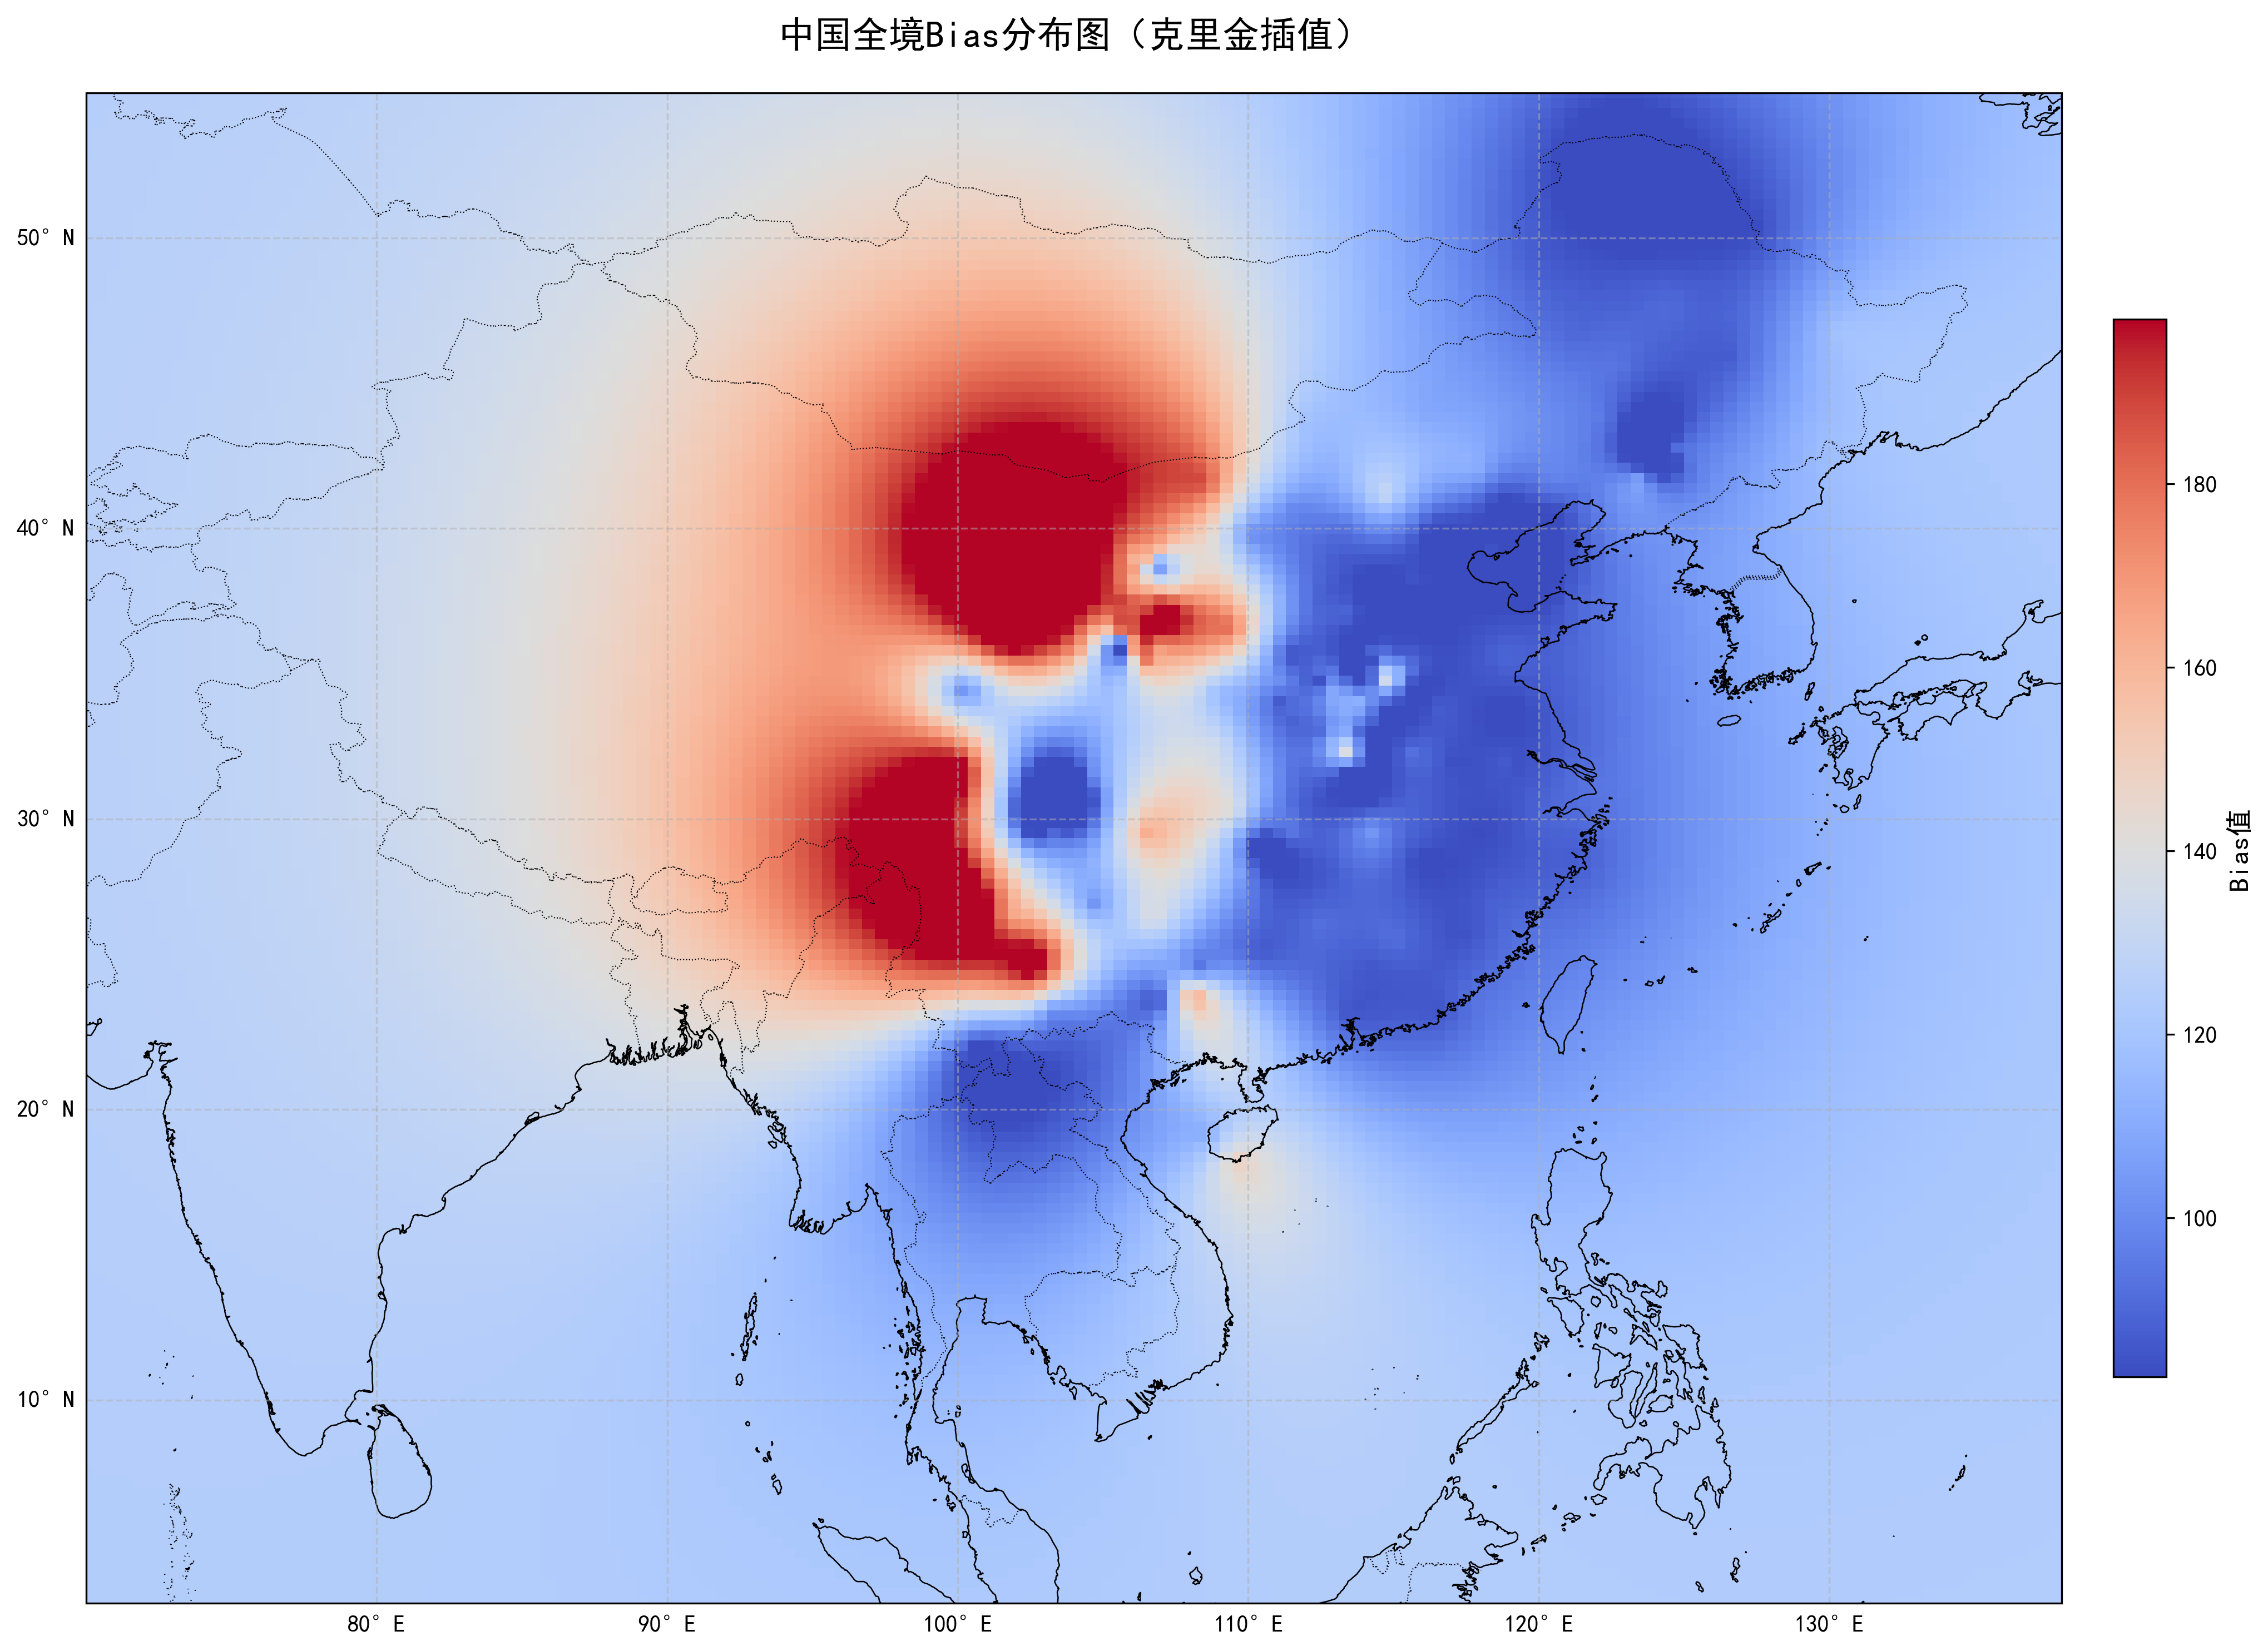

In [4]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging  # 引入克里金插值库

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，包含中国全境数据，并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 核心：将异常值替换为缺失值（NaN）
        # 包含9999、-999、999999，同时处理可能的字符串格式异常值
        异常值列表 = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(异常值列表, np.nan)
        
        # 过滤经纬度范围，并移除bias为缺失值的行
        valid_mask = (
            df['bias'].notna() &  # 仅保留非缺失的bias值
            df['Lon'].between(70, 138) &  # 东经70-138度
            df['Lat'].between(3, 55)      # 北纬3-55度
        )
        cleaned_df = df[valid_mask].copy()
        
        # 打印清洗信息（可选，用于调试）
        #print(f"文件 {os.path.basename(file)} 清洗后保留 {len(cleaned_df)} 条有效数据")
        return cleaned_df
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件并合并数据"""
    data_list = []
    for file in tqdm(file_list, desc="处理文件中"):
        try:
            filename = os.path.basename(file)
            date_str = filename.split('_')[-2][:8]
            date = datetime.strptime(date_str, "%Y%m%d").date()
            
            df = safe_read_csv(file)
            if df is not None and not df.empty:
                df['Date'] = date
                data_list.append(df[['Date', 'Lon', 'Lat', 'bias']])
        except Exception as e:
            print(f"处理文件 {filename} 时出错: {str(e)}")
    
    if not data_list:
        raise ValueError("未找到有效数据")
    all_data = pd.concat(data_list, ignore_index=True, copy=False)
    
    # 再次检查并清洗合并后的数据（双重保障）
    # all_data['bias'] = all_data['bias'].replace([9999, -999, 999999], np.nan).dropna() # 去除NaN
    # print(f"所有文件合并后共保留 {len(all_data)} 条有效数据")
    return all_data

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """使用普通克里金方法进行插值"""
    # 创建网格点
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    # 执行克里金插值（尝试更稳健的模型）
    OK = OrdinaryKriging(
        lon, lat, values, 
        variogram_model='exponential',  # 指数模型可能更适合部分数据
        verbose=False, 
        enable_plotting=False,
        nlags=8,  # 增加滞后距离数，提高稳定性
    )
    
    # 插值计算
    z, ss = OK.execute('grid', gridx, gridy)
    return z

def plot_china_bias(data):
    """绘制覆盖中国全境的Bias填色图（使用克里金插值）"""
    # 计算站点平均值（所有日期）
    station_avg = data.groupby(['Lon', 'Lat'], as_index=False)['bias'].mean()
    
    # 再次清洗平均值中的异常值（防止极端值影响）
    bias_mean = station_avg['bias'].mean()
    bias_std = station_avg['bias'].std()
    # 保留均值±3倍标准差范围内的数据（3σ准则）
    station_avg = station_avg[
        (station_avg['bias'] >= bias_mean - 3*bias_std) &
        (station_avg['bias'] <= bias_mean + 3*bias_std)
    ]
    print(f"站点平均值清洗后保留 {len(station_avg)} 个有效站点")
    
    # 创建覆盖中国全境的网格
    grid_lon = np.linspace(70, 138, 150, dtype='float32')
    grid_lat = np.linspace(3, 55, 150, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 准备克里金插值数据
    lon = station_avg['Lon'].values
    lat = station_avg['Lat'].values
    bias = station_avg['bias'].values
    
    # 执行克里金插值
    print("正在执行克里金插值...（可能需要几分钟）")
    grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
    
    # 创建图形
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    
    # 添加高精度地图要素
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='#E6F7FF', alpha=0.2)
    
    # 设置中国全境范围
    ax.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    # 动态调整颜色映射范围（关键：基于实际数据分布）
    vmin = np.nanpercentile(grid_bias, 2)  # 排除2%的极端小值
    vmax = np.nanpercentile(grid_bias, 98)  # 排除2%的极端大值
    
    # 绘制填色图
    pcm = ax.pcolormesh(
        grid_lon, grid_lat, grid_bias,
        cmap='coolwarm',
        vmin=vmin, vmax=vmax,  # 自适应数据范围
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    # 添加颜色条
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Bias值', fontsize=12)
    
    # 添加网格和标题
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    plt.title('中国全境Bias分布图（克里金插值）', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()


def main():
    # 文件路径设置
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    all_data = process_files(file_list)
    
    # 绘制中国全境填色图
    print("生成中国全境Bias填色图...")
    plot_china_bias(all_data)

if __name__ == '__main__':
    main()

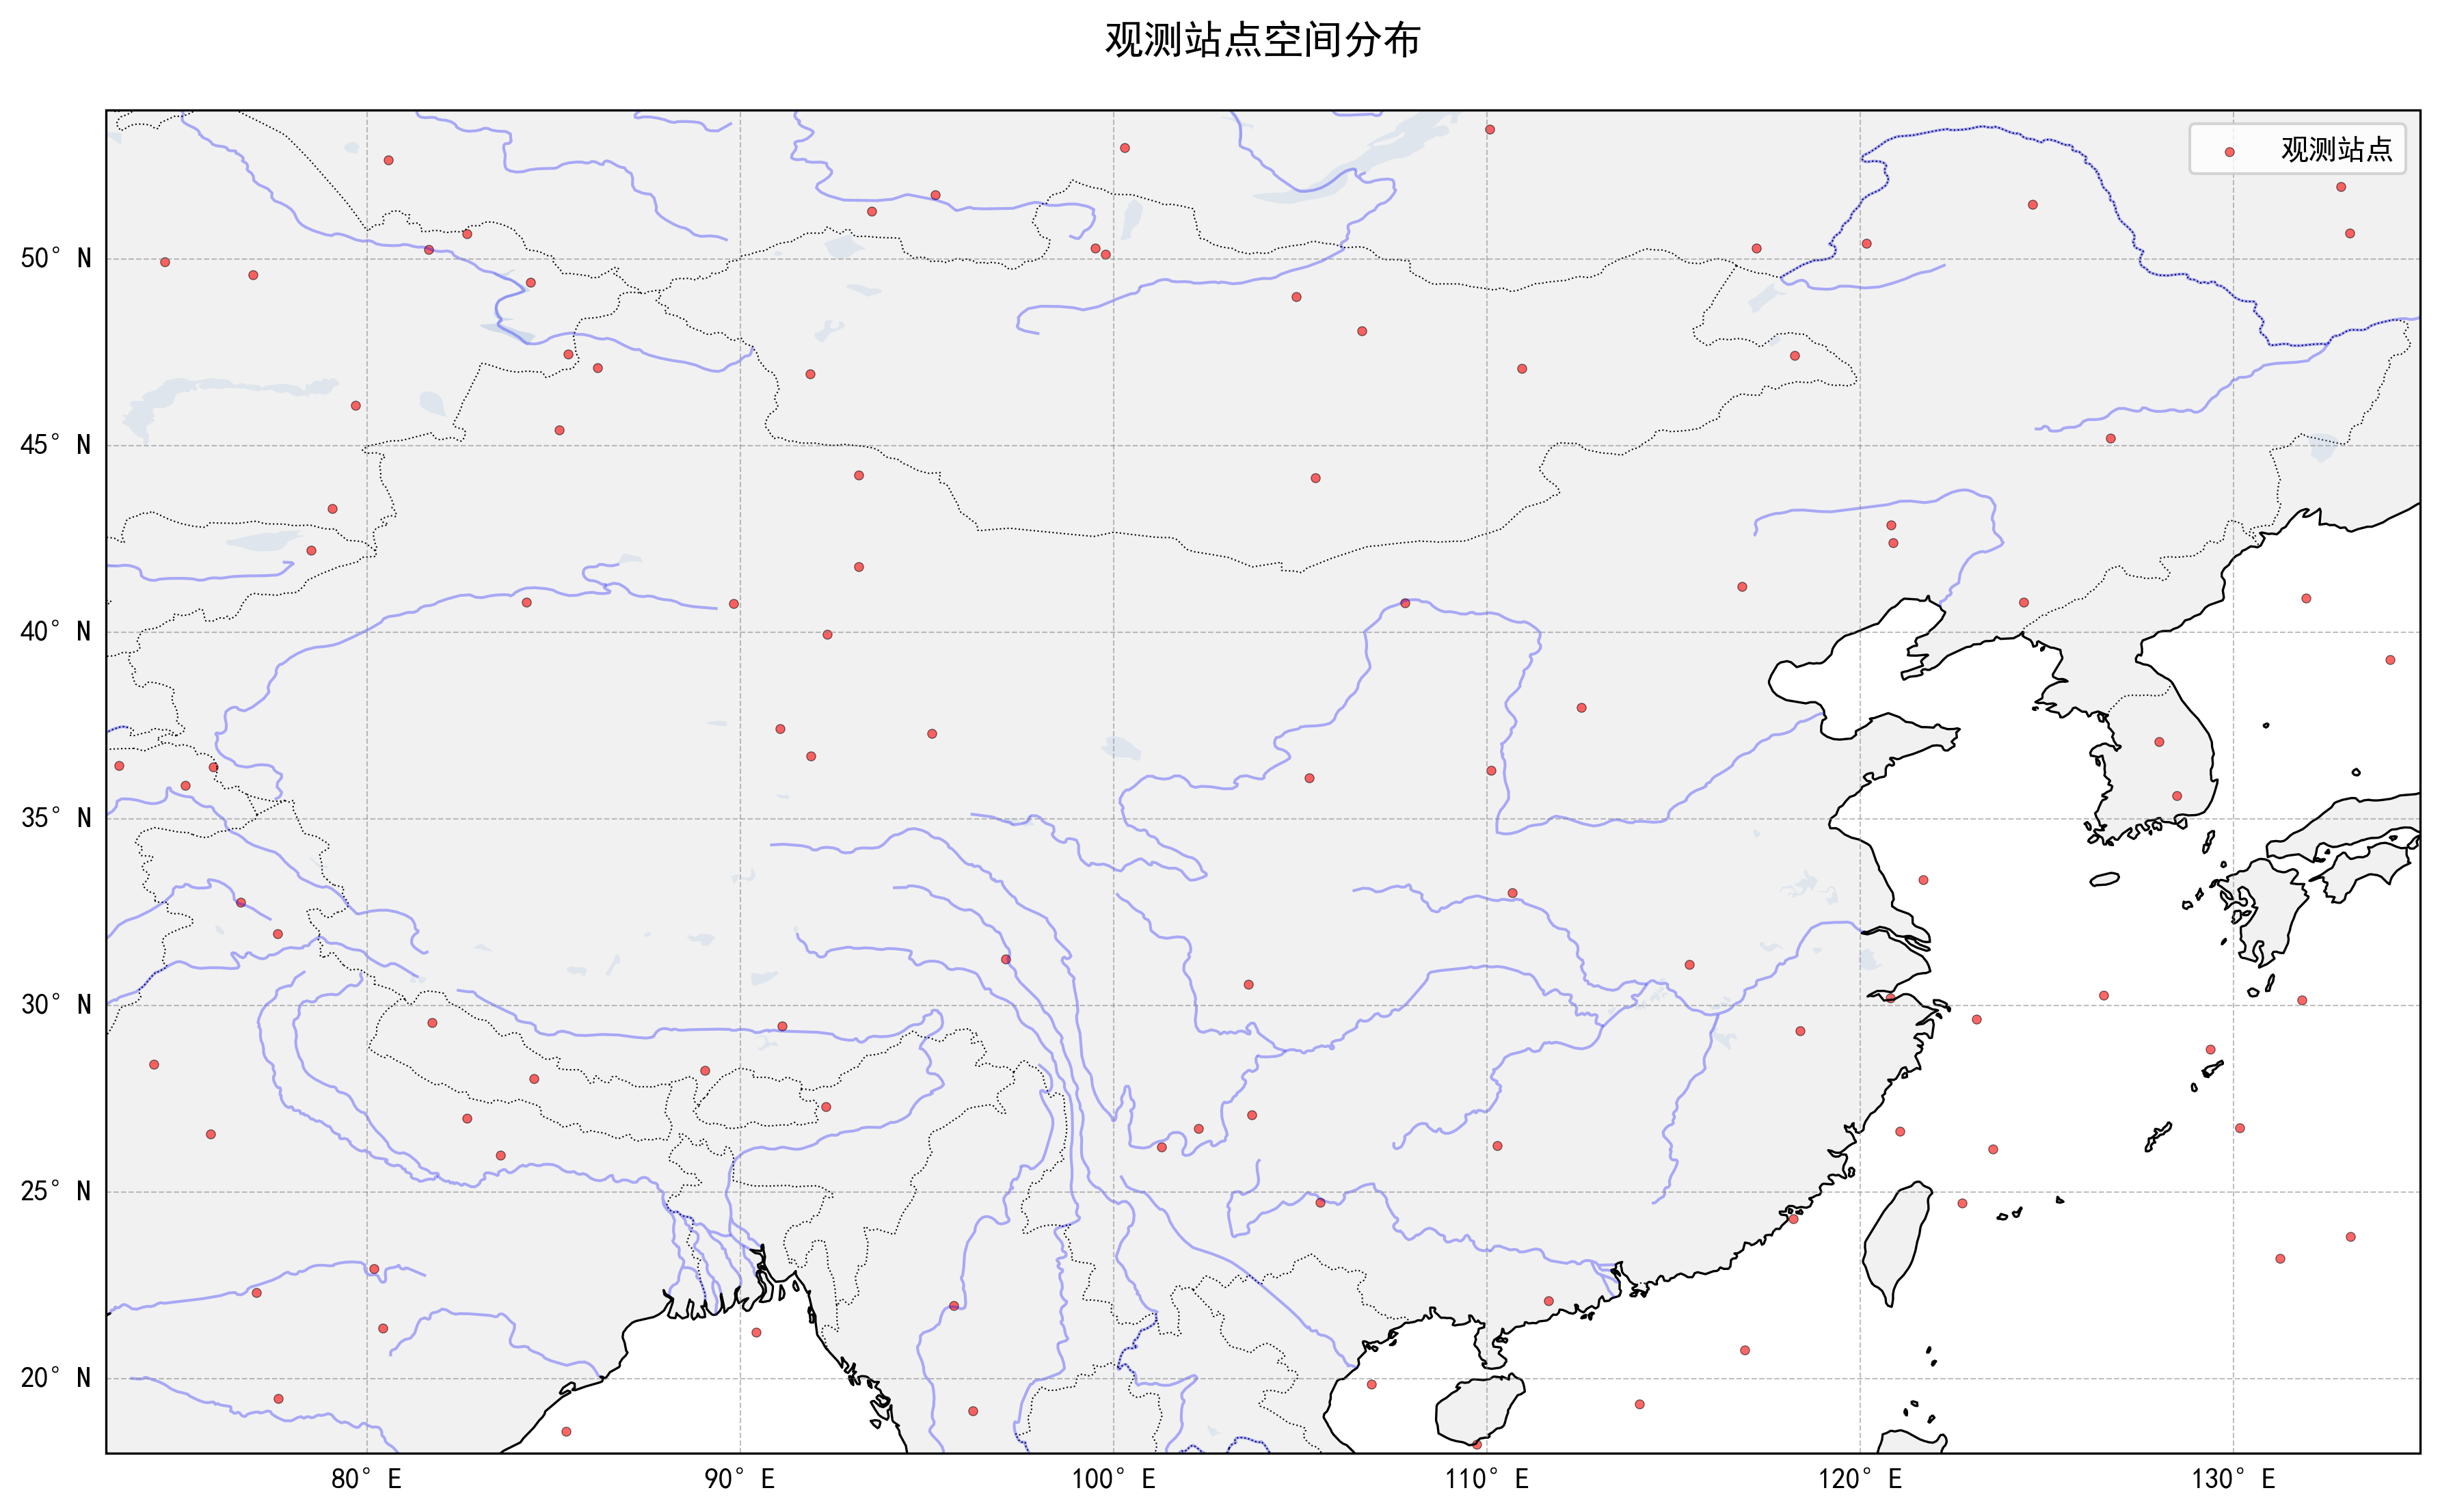

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_station_distribution(data):
    """
    绘制站点经纬度分布图
    参数:
        data: 包含'Lon'(经度)和'Lat'(纬度)列的DataFrame
    """
    # 创建图形和投影
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # 添加地图要素
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.LAKES, alpha=0.2)
    ax.add_feature(cfeature.RIVERS, edgecolor='blue', alpha=0.3)
    
    # 设置中国区域范围
    ax.set_extent([73, 135, 18, 54], crs=ccrs.PlateCarree())
    
    # 绘制站点分布
    scatter = ax.scatter(
        data['Lon'], 
        data['Lat'],
        c='red',         # 点颜色
        s=10,            # 点大小
        alpha=0.6,       # 透明度
        edgecolor='k',   # 边缘颜色
        linewidth=0.3,   # 边缘线宽
        transform=ccrs.PlateCarree(),
        label='观测站点'
    )
    
    # 添加网格和标签
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5, 
        color='gray', 
        alpha=0.5, 
        linestyle='--'
    )
    gl.top_labels = False   # 关闭顶部标签
    gl.right_labels = False # 关闭右侧标签
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    # 添加标题和图例
    plt.title('观测站点空间分布', fontsize=14, pad=20)
    plt.legend(loc='upper right')
    
    # 显示图形
    plt.tight_layout()
    plt.show()

# 使用示例（假设已有包含经纬度的DataFrame）
if __name__ == '__main__':
    # 示例数据生成（实际使用时替换为你的数据）
    import numpy as np
    np.random.seed(42)
    sample_data = pd.DataFrame({
        'Lon': np.random.uniform(73, 135, 100),  # 中国经度范围
        'Lat': np.random.uniform(18, 54, 100)     # 中国纬度范围
    })
    
    # 调用绘图函数
    plot_station_distribution(sample_data)

找到 744 个文件，开始处理...


处理文件中: 100%|██████████| 744/744 [00:01<00:00, 385.04it/s]


成功提取 633 个有效小时的数据
生成小时级动态分布图...
预处理所有小时的插值结果...


插值计算中: 100%|██████████| 633/633 [00:59<00:00, 10.66it/s]
C:\Users\111\AppData\Local\Temp\ipykernel_30844\783605191.py:245: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # 预留底部空间


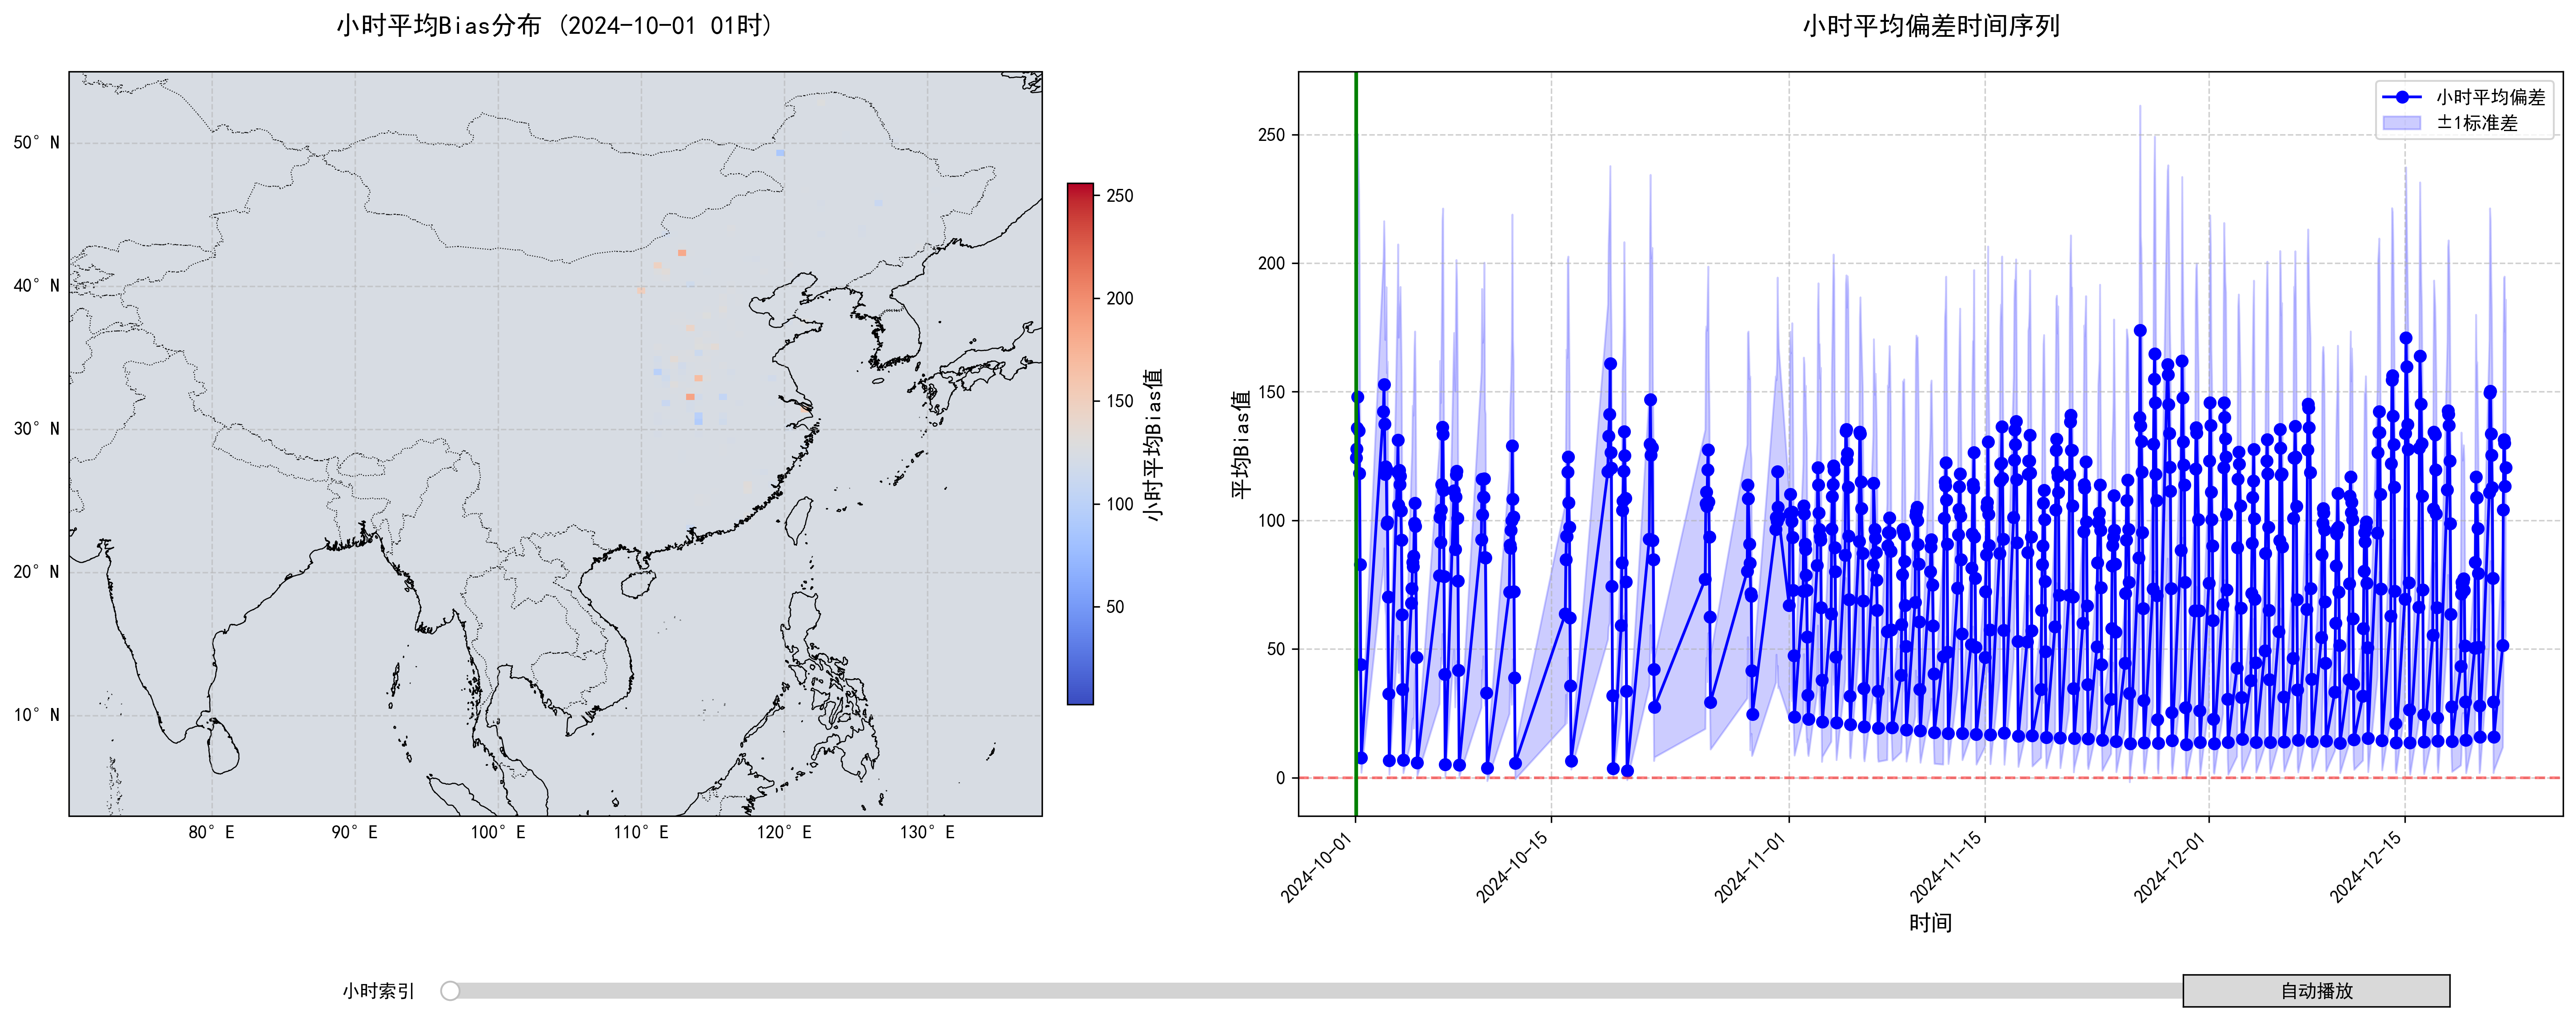

In [6]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider, Button

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，提取小时级时间并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 异常值处理
        abnormal_values = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(abnormal_values, np.nan)
        
        # 过滤经纬度范围和有效数据
        valid_mask = (
            df['bias'].notna() &
            df['Lon'].between(70, 138) &
            df['Lat'].between(3, 55)
        )
        cleaned_df = df[valid_mask].copy()
        
        # 从文件名提取小时级时间（假设文件名含YYYYMMDDHH）
        filename = os.path.basename(file)
        try:
            # 提取文件名中的时间字符串（例如：MSP3_..._2023070112_... → 2023070112）
            time_str = filename.split('_')[-2][:10]  # 取前10位（YYYYMMDDHH）
            dt = datetime.strptime(time_str, "%Y%m%d%H")  # 解析为小时级时间
            cleaned_df['datetime'] = dt  # 给该文件的所有数据标记小时时间
            return cleaned_df
        except:
            print(f"文件 {filename} 无法提取小时级时间，格式可能不符")
            return None
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件，按小时聚合站点数据"""
    all_data = []
    for file in tqdm(file_list, desc="处理文件中"):
        df = safe_read_csv(file)
        if df is not None and not df.empty:
            all_data.append(df)
    
    if not all_data:
        raise ValueError("未找到有效数据")
    
    # 合并所有数据并按小时+站点聚合（计算每个站点每小时的平均偏差）
    combined = pd.concat(all_data, ignore_index=True)
    # 按小时和经纬度分组，计算每个站点每小时的平均偏差
    hourly_data = combined.groupby(['datetime', 'Lon', 'Lat'])['bias'].mean().reset_index()
    
    # 按时间排序
    hourly_data = hourly_data.sort_values('datetime')
    unique_hours = sorted(hourly_data['datetime'].unique())
    print(f"成功提取 {len(unique_hours)} 个有效小时的数据")
    return hourly_data, unique_hours

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """克里金插值（适配小时级数据）"""
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    if len(lon) < 3:  # 数据点太少时返回空
        return np.full((len(gridy), len(gridx)), np.nan)
    
    try:
        OK = OrdinaryKriging(
            lon, lat, values, 
            variogram_model='exponential',
            verbose=False, 
            enable_plotting=False,
            nlags=8,
        )
        z, _ = OK.execute('grid', gridx, gridy)
        return z
    except:
        return np.full((len(gridy), len(gridx)), np.nan)

def plot_hourly_changes(hourly_data, unique_hours):
    """绘制小时级动态分布图+时间序列趋势"""
    # 创建共用网格
    grid_lon = np.linspace(70, 138, 120, dtype='float32')  # 适当降低分辨率提高速度
    grid_lat = np.linspace(3, 55, 120, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 预处理所有小时的插值结果和全局统计量
    interpolated = []  # 存储每个小时的插值结果
    hourly_stats = []  # 存储每个小时的整体统计（用于时间序列）
    
    # 计算全局颜色范围（避免小时间颜色跳变）
    all_biases = hourly_data['bias'].dropna().values
    global_vmin = np.nanpercentile(all_biases, 2)
    global_vmax = np.nanpercentile(all_biases, 98)
    
    # 提前计算每个小时的插值结果
    print("预处理所有小时的插值结果...")
    for dt in tqdm(unique_hours, desc="插值计算中"):
        # 提取该小时的数据
        hour_data = hourly_data[hourly_data['datetime'] == dt]
        
        # 3σ清洗该小时的异常值
        if len(hour_data) > 5:
            mean_val = hour_data['bias'].mean()
            std_val = hour_data['bias'].std()
            hour_data = hour_data[(hour_data['bias'] >= mean_val - 3*std_val) &
                                 (hour_data['bias'] <= mean_val + 3*std_val)]
        
        # 插值
        lon = hour_data['Lon'].values
        lat = hour_data['Lat'].values
        bias = hour_data['bias'].values
        grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
        interpolated.append(grid_bias)
        
        # 记录该小时的整体统计（用于时间序列）
        hourly_stats.append({
            'datetime': dt,
            'mean_bias': hour_data['bias'].mean(),
            'std_bias': hour_data['bias'].std()
        })
    
    # 创建双面板图形（左：空间分布，右：时间序列）
    fig = plt.figure(figsize=(20, 8))
    ax_map = fig.add_subplot(121, projection=ccrs.PlateCarree())  # 左：空间分布图
    ax_ts = fig.add_subplot(122)  # 右：时间序列图
    plt.subplots_adjust(bottom=0.2)  # 底部留空间放滑动条
    
    # ----------------------
    # 左侧：空间分布图初始化
    # ----------------------
    ax_map.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax_map.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax_map.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    # 初始空间分布
    pcm = ax_map.pcolormesh(
        grid_lon, grid_lat, interpolated[0],
        cmap='coolwarm',
        vmin=global_vmin, vmax=global_vmax,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    # 颜色条
    cbar = fig.colorbar(pcm, ax=ax_map, shrink=0.7, pad=0.02)
    cbar.set_label('小时平均Bias值', fontsize=12)
    
    # 网格和标题
    gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    map_title = ax_map.set_title(
        f'小时平均Bias分布 ({unique_hours[0].strftime("%Y-%m-%d %H时")})',
        fontsize=14, pad=20
    )
    
    # ----------------------
    # 右侧：时间序列图初始化
    # ----------------------
    ts_dates = [stat['datetime'] for stat in hourly_stats]
    ts_means = [stat['mean_bias'] for stat in hourly_stats]
    ts_stds = [stat['std_bias'] for stat in hourly_stats]
    
    # 绘制时间序列（均值±标准差）
    ax_ts.plot(ts_dates, ts_means, 'o-', color='blue', label='小时平均偏差')
    ax_ts.fill_between(
        ts_dates,
        [m - s for m, s in zip(ts_means, ts_stds)],
        [m + s for m, s in zip(ts_means, ts_stds)],
        color='blue', alpha=0.2, label='±1标准差'
    )
    ax_ts.axhline(y=0, color='red', linestyle='--', alpha=0.5)  # 零偏差参考线
    ax_ts.set_title('小时平均偏差时间序列', fontsize=14, pad=20)
    ax_ts.set_xlabel('时间', fontsize=12)
    ax_ts.set_ylabel('平均Bias值', fontsize=12)
    ax_ts.grid(True, linestyle='--', alpha=0.6)
    ax_ts.legend()
    plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=45, ha='right')  # 旋转时间标签
    
    # 添加当前时刻标记线
    vline = ax_ts.axvline(x=ts_dates[0], color='green', linestyle='-', linewidth=2, label='当前时刻')
    
    # ----------------------
    # 滑动条控制
    # ----------------------
    ax_slider = plt.axes([0.2, 0.05, 0.65, 0.03])
    slider = Slider(
        ax=ax_slider,
        label='小时索引',
        valmin=0,
        valmax=len(unique_hours)-1,
        valinit=0,
        valstep=1
    )
    
    # 滑动条更新函数
    def update(frame):
        dt = unique_hours[frame]
        # 更新空间分布图
        pcm.set_array(interpolated[frame].ravel())
        map_title.set_text(f'小时平均Bias分布 ({dt.strftime("%Y-%m-%d %H时")})')
        
        # 更新时间序列标记线
        vline.set_xdata([dt])
        
        fig.canvas.draw_idle()
    
    slider.on_changed(update)
    
    # ----------------------
    # 自动播放按钮
    # ----------------------
    def animate(event):
        for i in range(len(unique_hours)):
            slider.set_val(i)
            plt.pause(0.8)  # 每小时停留0.8秒
    
    ax_button = plt.axes([0.85, 0.05, 0.1, 0.03])
    button = Button(ax_button, '自动播放')
    button.on_clicked(animate)
    
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # 预留底部空间
    plt.show()

def main():
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    hourly_data, unique_hours = process_files(file_list)
    
    # 绘制小时级动态图和时间序列
    print("生成小时级动态分布图...")
    plot_hourly_changes(hourly_data, unique_hours)

if __name__ == '__main__':
    main()

找到 744 个文件，开始处理...


处理文件中: 100%|██████████| 744/744 [00:02<00:00, 364.59it/s]


成功提取 11 个小时的数据（0-23时）
生成小时级动态分布图...
预处理所有小时的插值结果...


插值计算中: 100%|██████████| 11/11 [00:01<00:00,  7.90it/s]
C:\Users\111\AppData\Local\Temp\ipykernel_22216\124774580.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.15, 1, 1])  # 预留底部控件空间


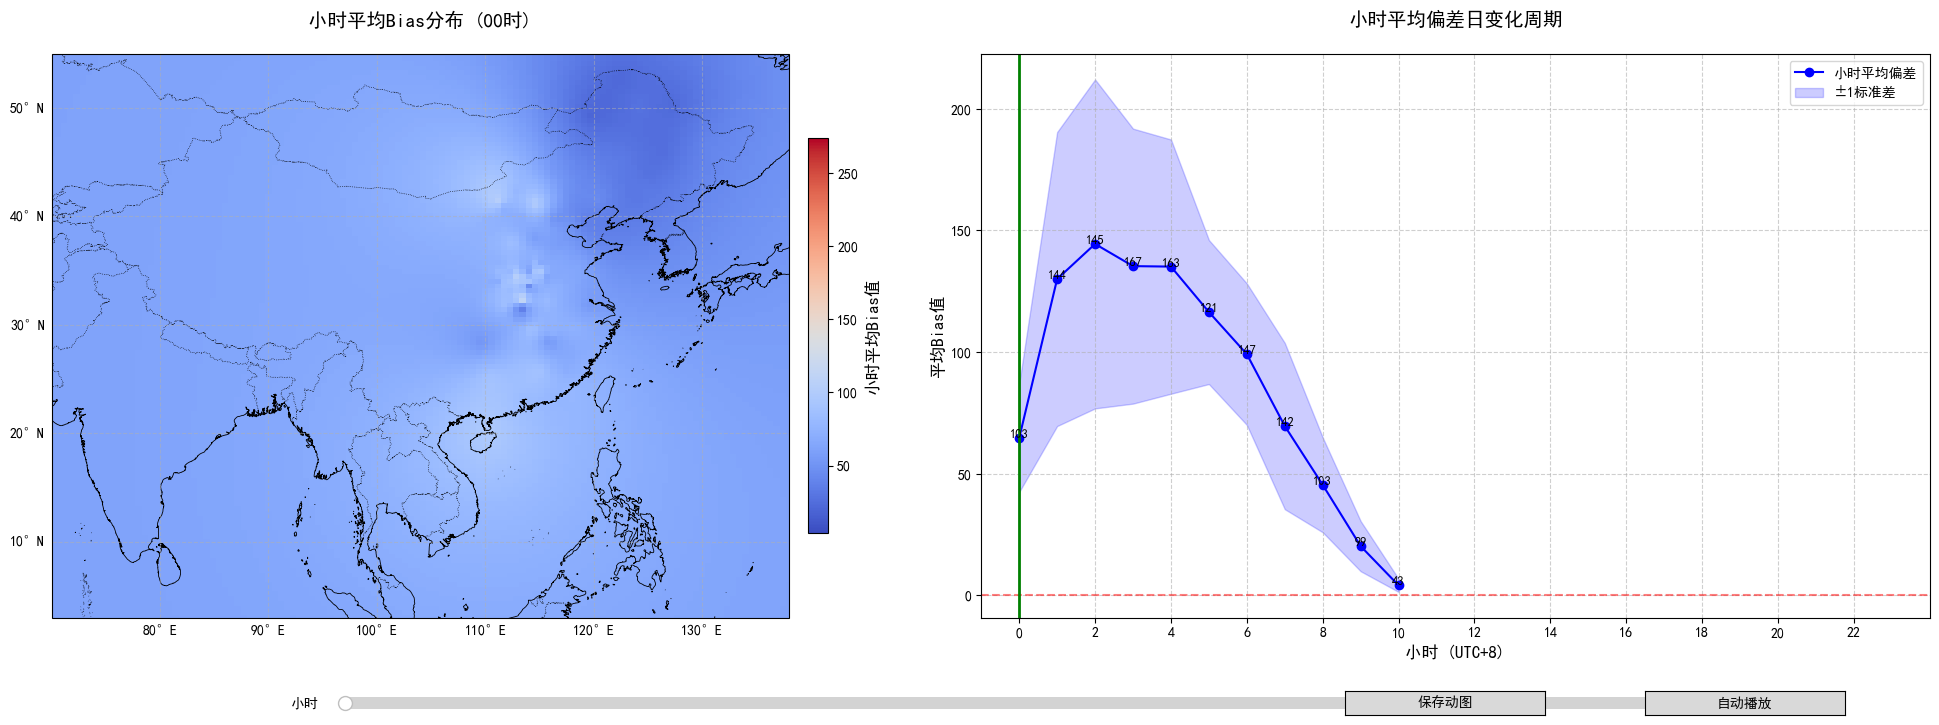

In [3]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
from tqdm import tqdm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from pykrige.ok import OrdinaryKriging
from matplotlib.animation import FuncAnimation, PillowWriter  # 新增动画保存相关库
from matplotlib.widgets import Slider, Button

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def safe_read_csv(file):
    """安全读取CSV文件，提取小时信息并清洗异常值"""
    try:
        df = pd.read_csv(
            file,
            usecols=['Lon', 'Lat', 'bias'],
            dtype={'Lon': 'float32', 'Lat': 'float32', 'bias': 'float32'},
            engine='c'
        )
        
        # 异常值处理
        abnormal_values = [9999, -999, 999999, '9999', '-999', '999999', 'NaN', 'NA']
        df['bias'] = df['bias'].replace(abnormal_values, np.nan)
        
        # 过滤经纬度范围和有效数据
        valid_mask = (
            df['bias'].notna() &
            df['Lon'].between(70, 138) &
            df['Lat'].between(3, 55)
        )
        cleaned_df = df[valid_mask].copy()
        
        # 从文件名提取小时信息（忽略日期，只保留小时）
        filename = os.path.basename(file)
        try:
            time_str = filename.split('_')[-2][8:10]  # 提取小时部分（如"12"）
            hour = int(time_str)
            cleaned_df['hour'] = hour  # 给该文件的所有数据标记小时（0-23）
            return cleaned_df
        except:
            print(f"文件 {filename} 无法提取小时信息，格式可能不符")
            return None
    except Exception as e:
        print(f"读取文件 {os.path.basename(file)} 出错: {str(e)}")
        return None

def process_files(file_list):
    """处理所有文件，按小时（0-23）聚合所有站点数据"""
    all_data = []
    for file in tqdm(file_list, desc="处理文件中"):
        df = safe_read_csv(file)
        if df is not None and not df.empty:
            all_data.append(df)
    
    if not all_data:
        raise ValueError("未找到有效数据")
    
    # 合并所有数据并按小时+站点聚合（跨天平均）
    combined = pd.concat(all_data, ignore_index=True)
    
    # 按小时和经纬度分组，计算每个站点在各小时的平均偏差（跨所有天）
    hourly_data = combined.groupby(['hour', 'Lon', 'Lat'])['bias'].mean().reset_index()
    
    # 按小时排序
    unique_hours = sorted(hourly_data['hour'].unique())
    print(f"成功提取 {len(unique_hours)} 个小时的数据（0-23时）")
    return hourly_data, unique_hours

def kriging_interpolation(lon, lat, values, grid_lon, grid_lat):
    """克里金插值"""
    gridx = np.linspace(np.min(grid_lon), np.max(grid_lon), len(grid_lon))
    gridy = np.linspace(np.min(grid_lat), np.max(grid_lat), len(grid_lat))
    
    if len(lon) < 3:  # 数据点太少时返回空
        return np.full((len(gridy), len(gridx)), np.nan)
    
    try:
        OK = OrdinaryKriging(
            lon, lat, values, 
            variogram_model='exponential',
            verbose=False, 
            enable_plotting=False,
            nlags=8,
        )
        z, _ = OK.execute('grid', gridx, gridy)
        return z
    except:
        return np.full((len(gridy), len(gridx)), np.nan)

def plot_hourly_changes(hourly_data, unique_hours):
    """绘制小时级动态分布图+日变化周期图（增加保存功能）"""
    # 创建共用网格
    grid_lon = np.linspace(70, 138, 120, dtype='float32')
    grid_lat = np.linspace(3, 55, 120, dtype='float32')
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # 预处理所有小时的插值结果和全局统计量
    interpolated = []  # 存储每个小时的插值结果
    hourly_stats = []  # 存储每个小时的整体统计（用于日变化图）
    
    # 计算全局颜色范围（避免小时间颜色跳变）
    all_biases = hourly_data['bias'].dropna().values
    global_vmin = np.nanpercentile(all_biases, 2)
    global_vmax = np.nanpercentile(all_biases, 98)
    
    # 提前计算每个小时的插值结果
    print("预处理所有小时的插值结果...")
    for hour in tqdm(unique_hours, desc="插值计算中"):
        # 提取该小时的数据
        hour_data = hourly_data[hourly_data['hour'] == hour]
        
        # 3σ清洗该小时的异常值
        if len(hour_data) > 5:
            mean_val = hour_data['bias'].mean()
            std_val = hour_data['bias'].std()
            hour_data = hour_data[(hour_data['bias'] >= mean_val - 3*std_val) &
                                 (hour_data['bias'] <= mean_val + 3*std_val)]
        
        # 插值
        lon = hour_data['Lon'].values
        lat = hour_data['Lat'].values
        bias = hour_data['bias'].values
        grid_bias = kriging_interpolation(lon, lat, bias, grid_lon[0], grid_lat[:,0])
        interpolated.append(grid_bias)
        
        # 记录该小时的整体统计（用于日变化图）
        hourly_stats.append({
            'hour': hour,
            'mean_bias': hour_data['bias'].mean(),
            'std_bias': hour_data['bias'].std(),
            'count': len(hour_data)  # 有效站点数
        })
    
    # 创建双面板图形（左：空间分布，右：日变化周期）
    fig = plt.figure(figsize=(20, 8))
    ax_map = fig.add_subplot(121, projection=ccrs.PlateCarree())  # 左：空间分布图
    ax_diurnal = fig.add_subplot(122)  # 右：日变化周期图
    plt.subplots_adjust(bottom=0.25)  # 增加底部空间，容纳保存按钮
    
    # ----------------------
    # 左侧：空间分布图初始化
    # ----------------------
    ax_map.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.5)
    ax_map.add_feature(cfeature.LAND, facecolor='#F0F0F0', alpha=0.3)
    ax_map.set_extent([70, 138, 3, 55], crs=ccrs.PlateCarree())
    
    # 初始空间分布
    pcm = ax_map.pcolormesh(
        grid_lon, grid_lat, interpolated[0],
        cmap='coolwarm',
        vmin=global_vmin, vmax=global_vmax,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    
    # 颜色条
    cbar = fig.colorbar(pcm, ax=ax_map, shrink=0.7, pad=0.02)
    cbar.set_label('小时平均Bias值', fontsize=12)
    
    # 网格和标题
    gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    map_title = ax_map.set_title(
        f'小时平均Bias分布 (0{unique_hours[0]}时)',
        fontsize=14, pad=20
    )
    
    # ----------------------
    # 右侧：日变化周期图初始化
    # ----------------------
    # 准备日变化数据
    hours = [stat['hour'] for stat in hourly_stats]
    means = [stat['mean_bias'] for stat in hourly_stats]
    stds = [stat['std_bias'] for stat in hourly_stats]
    
    # 绘制日变化曲线（均值±标准差）
    ax_diurnal.plot(hours, means, 'o-', color='blue', label='小时平均偏差')
    ax_diurnal.fill_between(
        hours,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color='blue', alpha=0.2, label='±1标准差'
    )
    ax_diurnal.axhline(y=0, color='red', linestyle='--', alpha=0.5)  # 零偏差参考线
    
    # 添加每个小时的样本数（站点数）
    for i, stat in enumerate(hourly_stats):
        ax_diurnal.text(stat['hour'], stat['mean_bias'] + 0.1, 
                       f"{stat['count']}", ha='center', fontsize=9)
    
    # 设置X轴为24小时制
    ax_diurnal.set_xticks(range(0, 24, 2))  # 每2小时一个刻度
    ax_diurnal.set_xlim(-1, 24)  # 稍微扩展边界
    ax_diurnal.set_title('小时平均偏差日变化周期', fontsize=14, pad=20)
    ax_diurnal.set_xlabel('小时 (UTC+8)', fontsize=12)
    ax_diurnal.set_ylabel('平均Bias值', fontsize=12)
    ax_diurnal.grid(True, linestyle='--', alpha=0.6)
    ax_diurnal.legend()
    
    # 添加当前时刻标记线
    vline = ax_diurnal.axvline(x=hours[0], color='green', linestyle='-', linewidth=2, label='当前时刻')
    
    # ----------------------
    # 交互控件（新增保存按钮）
    # ----------------------
    # 滑动条控制
    ax_slider = plt.axes([0.2, 0.1, 0.65, 0.03])
    slider = Slider(
        ax=ax_slider,
        label='小时',
        valmin=0,
        valmax=len(unique_hours)-1,
        valinit=0,
        valstep=1
    )
    
    # 自动播放按钮
    ax_button = plt.axes([0.85, 0.1, 0.1, 0.03])
    play_button = Button(ax_button, '自动播放')
    
    # 保存动画按钮（新增）
    ax_save = plt.axes([0.7, 0.1, 0.1, 0.03])
    save_button = Button(ax_save, '保存动图')
    
    # ----------------------
    # 交互功能实现（含保存逻辑）
    # ----------------------
    # 滑动条更新函数
    def update(frame):
        frame = int(frame)  # 确保是整数索引
        hour = unique_hours[frame]
        # 更新空间分布图
        pcm.set_array(interpolated[frame].ravel())
        map_title.set_text(f'小时平均Bias分布 ({hour:02d}时)')
        
        # 更新日变化周期标记线
        vline.set_xdata([hour])
        
        fig.canvas.draw_idle()
    
    slider.on_changed(update)
    
    # 自动播放函数
    def animate(event):
        for i in range(len(unique_hours)):
            slider.set_val(i)
            plt.pause(0.8)  # 每小时停留0.8秒
    
    play_button.on_clicked(animate)
    
    # 保存动图函数（核心新增功能）
    def save_animation(event):
        print("开始保存动图...（可能需要几秒到几分钟）")
        
        # 定义动画帧更新函数（用于生成GIF）
        def animate_frame(i):
            update(i)  # 复用滑动条的更新逻辑
            return pcm, vline  # 返回需要更新的元素
        
        # 创建动画对象
        ani = FuncAnimation(
            fig, 
            animate_frame, 
            frames=len(unique_hours),  # 总帧数=小时数
            interval=800,  # 每帧停留800毫秒（与自动播放速度一致）
            blit=True  # 只更新变化的部分，加速渲染
        )
        
        # 保存为GIF（使用Pillow库，兼容性好）
        save_path = "hourly_bias_animation.gif"
        ani.save(
            save_path,
            writer=PillowWriter(fps=1.25),  # 1.25帧/秒 = 每帧0.8秒
            dpi=150  # 控制清晰度（值越高文件越大）
        )
        
        print(f"动图已保存至：{os.path.abspath(save_path)}")
        print("可在文件管理器中找到该GIF文件，双击即可播放")
    
    save_button.on_clicked(save_animation)  # 绑定保存按钮事件
    
    plt.tight_layout(rect=[0, 0.15, 1, 1])  # 预留底部控件空间
    plt.show()

def main():
    base_path = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
    file_pattern = os.path.join(base_path, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*_0000-0000.CSV")
    file_list = glob.glob(file_pattern, recursive=True)
    
    if not file_list:
        raise FileNotFoundError("未找到匹配的文件")
    
    print(f"找到 {len(file_list)} 个文件，开始处理...")
    hourly_data, unique_hours = process_files(file_list)
    
    # 绘制小时级动态图和日变化周期
    print("生成小时级动态分布图...")
    plot_hourly_changes(hourly_data, unique_hours)

if __name__ == '__main__':
    main()